FPS = 51.415843611057646


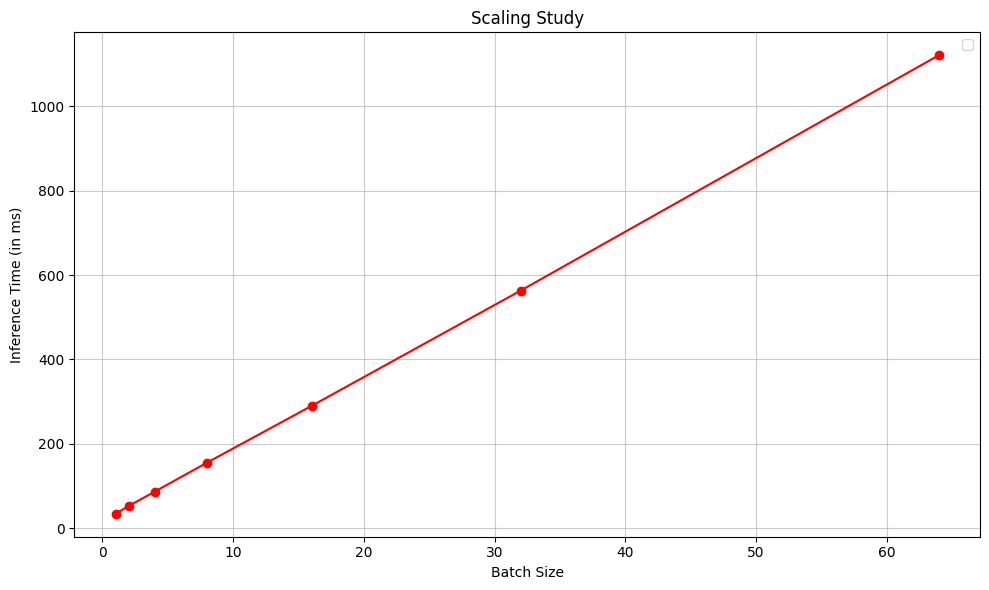

In [5]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import timm
import time

# Constants
device = torch.device('cuda')
NUM_WARMUPS = 5
NUM_RUNS = 10

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        
        self.encoder = timm.create_model('hf_hub:timm/mobilevit_s.cvnets_in1k', pretrained=True, features_only=True)
        
        self.dsc1 = DepthSepConv(in_channels=32, out_channels=16, kernel_size=4, stride=4, padding=0)
        self.dsc2 = DepthSepConv(in_channels=64, out_channels=32, kernel_size=2, stride=2, padding=0)
        self.dsc3 = DepthSepConv(in_channels=96, out_channels=48, kernel_size=1, stride=1, padding=0)
        self.dsct1 = DepthSepConvTranspose(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.dsct2 = DepthSepConvTranspose(in_channels=640, out_channels=320, kernel_size=4, stride=4, padding=0)

        self.dsc_red = DepthSepConv(in_channels=480, out_channels=240, kernel_size=3, stride=1, padding=1)
        
        self.dsct_combine = DepthSepConvTranspose(in_channels=720, out_channels=360, kernel_size=4, stride=4, padding=0)

        self.dyt1 = DyT(num_channels=360, init_alpha=0.5)

        self.pw1 = PointwiseConv(in_channels=360, out_channels=180)

        self.dsct_up = DepthSepConvTranspose(in_channels=540, out_channels=260, kernel_size=4, stride=2, padding=1)

        self.dyt2 = DyT(num_channels=260, init_alpha=0.5)  
        self.pw2 = PointwiseConv(in_channels=260, out_channels=130)

        self.final = DepthSepConv(in_channels=390, out_channels=1, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        
        f1, f2, f3, f4, f5 = self.encoder(x)
        
        f1 = self.dsc1(f1)
        f2 = self.dsc2(f2)
        f3 = self.dsc3(f3)
        f4 = self.dsct1(f4)
        f5 = self.dsct2(f5)

        x = torch.cat((f1, f2, f3, f4, f5), dim=1)
        
        store = x

        x = self.dsc_red(x)
        x = torch.cat((x, store), dim=1)
        
        x = self.dsct_combine(x)
        x = self.dyt1(x)

        store = x
        x = self.pw1(x)
        x = torch.cat((x, store), dim=1)
        x = self.dsct_up(x)

        x = self.dyt2(x)
        
        store = x
        x = self.pw2(x)
        x = torch.cat((x, store), dim=1)
        
        x = self.final(x)
        
        return x

class DyT(nn.Module):
    def __init__(self, num_channels, init_alpha=0.5):
        super(DyT, self).__init__()
        self.alpha = nn.Parameter(torch.ones(1) * init_alpha)
        self.gamma = nn.Parameter(torch.ones(1, num_channels, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, num_channels, 1, 1))

    def forward(self, x):
        x = torch.tanh(self.alpha * x)
        x = self.gamma * x + self.beta
        return x

class DepthSepConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(DepthSepConv, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        self.depthwise = nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channels, bias=False)
        self.pointwise = PointwiseConv(in_channels=in_channels, out_channels=out_channels)
        
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class PointwiseConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(PointwiseConv, self).__init__()
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.pointwise(x)

class DepthSepConvTranspose(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1):
        super(DepthSepConvTranspose, self).__init__()
        self.depthwise = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=kernel_size, 
                                            stride=stride, groups=in_channels, padding=padding, bias=False)
        self.pointwise = PointwiseConv(in_channels, out_channels)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

def get_inf_time(model):
    batches = [1, 2, 4, 8, 16, 32, 64]
    times = []

    model.to(device)
    model.eval()

    for batch in batches:
        dummy_ip = torch.randn((batch, 3, 224, 224)).to(device)
        loc_time = 0.0

        with torch.inference_mode():
            for _ in range(NUM_WARMUPS):
                _ = model(dummy_ip)

            for _ in range(NUM_RUNS):
                start = time.time()
                _ = model(dummy_ip)
                torch.cuda.synchronize()
                end = time.time()
                loc_time += (end - start)

        times.append((loc_time / NUM_RUNS) * 1000)

    return np.array(batches), np.array(times)
                

if __name__ == '__main__':
    
    model = torch.load('/kaggle/input/lightseg-finetuned/pytorch/default/1/Fine_Tuned.pth', weights_only=False, map_location=device)
    scripted_model = torch.jit.script(model)
    scripted_model.eval()
    
    batches, times = get_inf_time(scripted_model)

    print(f'FPS = {batches[3] / (times[3] / 1000)}')
    
    plt.figure(figsize=(10, 6))
    plt.plot(batches, times, color='red', marker='o')
    plt.xlabel('Batch Size')
    plt.ylabel('Inference Time (in ms)')
    plt.title('Scaling Study', fontsize=12)
    plt.grid(True, alpha=0.66)
    plt.legend()
    plt.tight_layout()
    plt.savefig('scaling_study.pdf', format='pdf', dpi=600)
    plt.show()

    scripted_model.save('scripted_fine_tuned.pt')

In [13]:
batches[3] / (times[3] * 1e-3)

51.415843611057646